# CELL MESH Demo: HNSC 200-cell h5ad Workflow

This notebook demonstrates the main CELL MESH analysis flow using `cellmesh/data/demo_HNSC_200cell.h5ad`:

1. Load an h5ad single-cell dataset.
2. Load packaged enzyme and sensor priors.
3. Filter priors to genes present in the h5ad file and select a small reproducible demo subset.
4. Run `run_cell_mesh()`.
5. Inspect communication events and draw a sender-receiver heatmap for one metabolite.


## 1. Imports


In [1]:
from pathlib import Path
import os

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cellmesh
from cellmesh import read_anndata, load_cell_mesh_database, run_cell_mesh
from cellmesh.ploting import plot_significant_event_counts, plot_event_dotplot

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 30)

print("cellmesh", cellmesh.__version__)
print("cellmesh path:", cellmesh.__file__)


cellmesh 0.4.0
cellmesh path: /home/qsong/.openclaw/workspace/developer/cell_mesh_pkg/cellmesh/__init__.py


## 2. Load the Demo h5ad File

The demo uses `Celltype (malignancy)` as the cell-group column because all three groups have enough cells in this 200-cell subset.


In [2]:
PACKAGE_ROOT = Path.cwd().parent if Path.cwd().name == "examples" else Path.cwd()
h5ad_path = PACKAGE_ROOT / "cellmesh" / "data" / "demo_HNSC_200cell.h5ad"

adata = read_anndata(h5ad_path, mode="h5ad")
cell_type_key = "Celltype (malignancy)"

print("h5ad:", h5ad_path)
print("shape:", adata.shape)
print("obs columns:", list(adata.obs.columns))
display(adata.obs[cell_type_key].value_counts().to_frame("n_cells"))


h5ad: /home/qsong/.openclaw/workspace/developer/cell_mesh_pkg/cellmesh/data/demo_HNSC_200cell.h5ad
shape: (200, 18241)
obs columns: ['UMAP_1', 'UMAP_2', 'Celltype (malignancy)', 'celltype', 'Celltype (minor-lineage)', 'Celltype (original)', 'cluster', 'Site', 'Celltype', 'Patient', 'Source', 'Age', 'Gender', 'Stage', 'TNMstage']


,n_cells
Celltype (malignancy),
Malignant cells,84
Stromal cells,68
Immune cells,48


## 3. Load and Filter Packaged Priors

`load_cell_mesh_database()` loads the packaged versioned priors. For a quick demo, the priors are filtered to genes present in the h5ad file and then restricted to the first 20 metabolite/HMDB pairs that have both enzyme and sensor evidence.


In [3]:
enzyme_metabolite, metabolite_sensor = load_cell_mesh_database()
genes_present = set(pd.Index(adata.var_names).astype(str))

enzyme_present = enzyme_metabolite[enzyme_metabolite["gene"].astype(str).isin(genes_present)].copy()
sensor_present = metabolite_sensor[metabolite_sensor["sensor_gene"].astype(str).isin(genes_present)].copy()

matched_pairs = sorted(
    set(zip(enzyme_present["metabolite"], enzyme_present["hmdb_id"]))
    .intersection(set(zip(sensor_present["metabolite"], sensor_present["hmdb_id"])))
)

MAX_METABOLITES = 20
selected_pairs = pd.DataFrame(matched_pairs[:MAX_METABOLITES], columns=["metabolite", "hmdb_id"])
enzyme_demo = enzyme_present.merge(selected_pairs, on=["metabolite", "hmdb_id"])
sensor_demo = sensor_present.merge(selected_pairs, on=["metabolite", "hmdb_id"])

print("loaded enzyme prior:", enzyme_metabolite.shape)
print("loaded sensor prior:", metabolite_sensor.shape)
print("enzyme rows with expressed genes:", enzyme_present.shape)
print("sensor rows with expressed genes:", sensor_present.shape)
print("matched metabolite/HMDB pairs:", len(matched_pairs))
print("demo enzyme prior:", enzyme_demo.shape)
print("demo sensor prior:", sensor_demo.shape)
display(selected_pairs.head(20))


loaded enzyme prior: (12799, 8)
loaded sensor prior: (9858, 9)
enzyme rows with expressed genes: (11757, 8)
sensor rows with expressed genes: (7746, 9)
matched metabolite/HMDB pairs: 245
demo enzyme prior: (80, 8)
demo sensor prior: (74, 9)


,metabolite,hmdb_id
0,(R)-5-Diphosphomevalonic acid,HMDB0001090
1,11-cis-Retinol,HMDB0006216
2,11beta-Hydroxyprogesterone,HMDB0004031
3,12-HETE,HMDB0006111
4,13-cis-Retinoic acid,HMDB0006219
5,15-HETE,HMDB0003876
6,16a-Hydroxyestrone,HMDB0000335
7,17-Hydroxyprogesterone,HMDB0000374
8,17alpha-Estradiol,HMDB0000429
9,2-Hydroxyestradiol,HMDB0000338


## 4. Run CELL MESH

This demo uses `min_cells=10` because the h5ad file contains 200 cells. The public default remains 100, which is appropriate for larger datasets. `n_perms=100` is used so empirical permutation p-values and FDR are available in the event table.


In [4]:
res = run_cell_mesh(
    adata,
    enzyme_metabolite=enzyme_demo,
    metabolite_sensor=sensor_demo,
    cell_type_key=cell_type_key,
    min_cells=10,
    min_expr_frac=0.05,
    allow_self=True,
    n_perms=100,
    random_state=0,
)

print("events:", res.events.shape)
print("sender_scores:", res.sender_scores.shape)
print("receiver_scores:", res.receiver_scores.shape)
print("availability result keys:", sorted(res.availability_results.keys()))
print("events with permutation p-value:", res.events["perm_pvalue"].notna().sum())
print("events with FDR:", res.events["fdr"].notna().sum())


events: (612, 15)
sender_scores: (16, 3)
receiver_scores: (222, 8)
availability result keys: ['C', 'C_contrast', 'E', 'E_contrast', 'E_plus', 'P', 'P_contrast', 'P_plus', 'availability', 'cell_counts', 'expr_frac', 'metadata', 'pseudobulk', 'reaction_genes', 'relative_consumption_support']
events with permutation p-value: 612
events with FDR: 612


## 5. Inspect Top Events


In [5]:
event_cols = [
    "sender",
    "receiver",
    "metabolite",
    "hmdb_id",
    "sensor_gene",
    "sensor_type",
    "metabolite_availability",
    "sensor_score",
    "cell_mesh_score",
    "perm_pvalue",
    "fdr",
    "confidence_tier",
]

display(res.events[event_cols].head(20))


,sender,receiver,metabolite,hmdb_id,sensor_gene,sensor_type,metabolite_availability,sensor_score,cell_mesh_score,perm_pvalue,fdr,confidence_tier
0,Malignant cells,Malignant cells,20-Hydroxy-leukotriene B4,HMDB0001509,LTB4R2,Cell surface receptor,0.995627,0.978553,0.987053,0.009901,0.140028,Tier3_exploratory
1,Malignant cells,Malignant cells,20-Hydroxy-leukotriene B4,HMDB0001509,LTB4R,Cell surface receptor,0.995627,0.918478,0.956275,0.009901,0.140028,Tier3_exploratory
2,Malignant cells,Stromal cells,17-Hydroxyprogesterone,HMDB0000374,NR2F2,Cell surface receptor,0.711441,0.816379,0.762106,0.009901,0.140028,Tier3_exploratory
3,Stromal cells,Malignant cells,25-Hydroxycholesterol,HMDB0006247,LPAR3,Cell surface receptor,0.327914,1.000000,0.572638,0.009901,0.140028,Tier3_exploratory
4,Stromal cells,Immune cells,27-Hydroxycholesterol,HMDB0002103,GPR183,Cell surface receptor,0.300170,0.872687,0.511815,0.009901,0.140028,Tier3_exploratory
5,Malignant cells,Malignant cells,15-HETE,HMDB0003876,LTB4R2,Cell surface receptor,0.101145,0.978553,0.314604,0.009901,0.140028,Tier3_exploratory
6,Malignant cells,Malignant cells,12-HETE,HMDB0006111,LTB4R2,Cell surface receptor,0.058930,0.978553,0.240137,0.009901,0.140028,Tier3_exploratory
7,Malignant cells,Stromal cells,20-Hydroxyeicosatetraenoic acid,HMDB0005998,TRPC6,Transporter,0.983846,1.000000,0.991890,0.009901,0.178218,Tier3_exploratory
8,Stromal cells,Stromal cells,3beta-Hydroxypregn-5-en-20-one sulfate,HMDB0060382,TRPM3,Transporter,0.837348,0.954129,0.893833,0.009901,0.178218,Tier3_exploratory
9,Stromal cells,Stromal cells,3beta-Hydroxypregn-5-en-20-one sulfate,HMDB0060382,TRPM1,Transporter,0.837348,0.505758,0.650765,0.019802,0.237624,Tier3_exploratory


In [6]:
len(res.events[event_cols])

612

## 6. Global Overview: Significant Communication Event Counts

This visualization summarizes significant metabolite-sensor communication events from each sender group to each receiver group. By default, it displays events with `fdr <= 0.05`; adjust `min_cell_mesh_score`, `max_perm_pvalue`, or `max_fdr` to inspect broader or stricter event sets. Each tile shows the number of unique `metabolite + HMDB ID + sensor_gene` combinations retained for that sender-receiver direction.


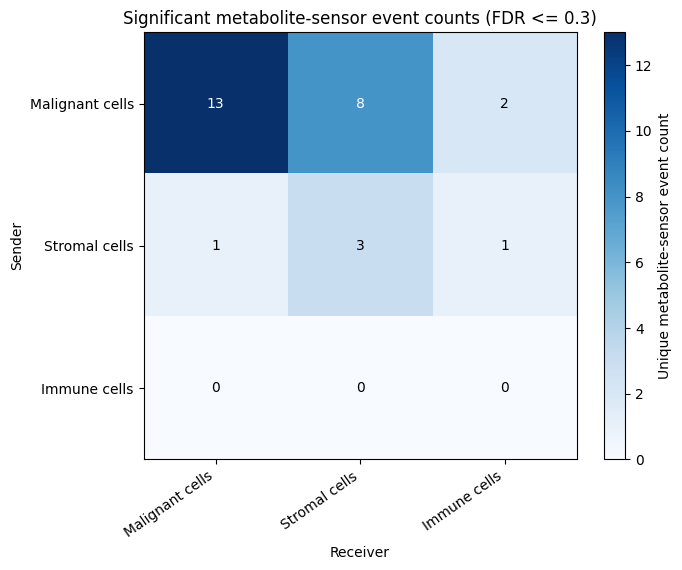

{'min_cell_mesh_score': None, 'max_perm_pvalue': None, 'max_fdr': 0.3, 'events_before_filter': 612, 'events_after_filter': 28, 'unique_events_after_filter': 28}


,sender,receiver,metabolite_sensor_count
0,Malignant cells,Malignant cells,13
1,Malignant cells,Stromal cells,8
4,Stromal cells,Stromal cells,3
2,Malignant cells,Immune cells,2
3,Stromal cells,Malignant cells,1
5,Stromal cells,Immune cells,1


In [7]:
assert not res.events.empty

# Threshold controls. Set a value to enable a filter, or keep None to ignore it.
min_cell_mesh_score = None
max_perm_pvalue = None
max_fdr = 0.3

sig_overview = plot_significant_event_counts(
    res,
    min_cell_mesh_score=min_cell_mesh_score,
    max_perm_pvalue=max_perm_pvalue,
    max_fdr=max_fdr,
)
plt.show()

print(sig_overview["thresholds"])
global_event_counts = sig_overview["counts"]
pair_event_summary = sig_overview["all_summary"]
filtered_events = sig_overview["filtered_events"]

display(sig_overview["summary"])


## 7. Dotplot: Top Metabolite-Sensor Communication Events

This dotplot follows the common sender-receiver event visualization pattern: rows are metabolite-sensor events, columns are sender-to-receiver pairs, color encodes `cell_mesh_score`, and bubble size encodes `-log10(FDR)`. Leave `event_keys=None` to display the top `top_n` events by FDR, or provide specific `(metabolite, hmdb_id, sensor_gene)` tuples to inspect selected communication events across all sender-receiver pairs.


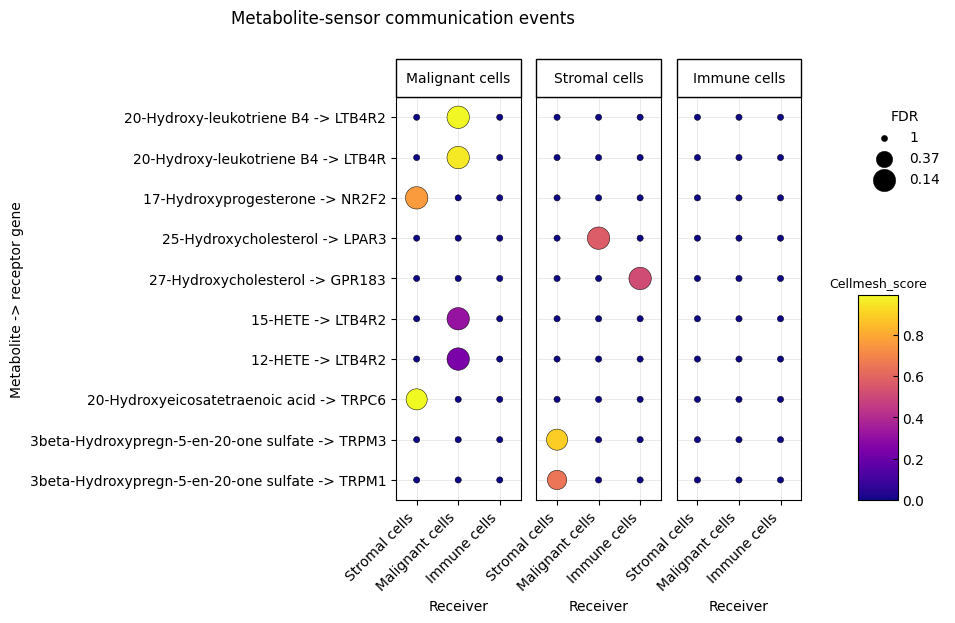

{'top_n': 10, 'event_keys': None, 'min_cell_mesh_score': None, 'max_perm_pvalue': None, 'max_fdr': None, 'events_before_filter': 612, 'events_after_filter': 612, 'events_plotted': 90}


,sender,receiver,metabolite,hmdb_id,sensor_gene,cell_mesh_score,perm_pvalue,fdr
343,Immune cells,Immune cells,12-HETE,HMDB0006111,LTB4R2,0.000000,1.000000,1.000000
337,Immune cells,Malignant cells,12-HETE,HMDB0006111,LTB4R2,0.000000,1.000000,1.000000
340,Immune cells,Stromal cells,12-HETE,HMDB0006111,LTB4R2,0.000000,1.000000,1.000000
351,Malignant cells,Immune cells,12-HETE,HMDB0006111,LTB4R2,0.000000,1.000000,1.000000
6,Malignant cells,Malignant cells,12-HETE,HMDB0006111,LTB4R2,0.240137,0.009901,0.140028
338,Malignant cells,Stromal cells,12-HETE,HMDB0006111,LTB4R2,0.000000,1.000000,1.000000
342,Stromal cells,Immune cells,12-HETE,HMDB0006111,LTB4R2,0.000000,1.000000,1.000000
336,Stromal cells,Malignant cells,12-HETE,HMDB0006111,LTB4R2,0.000000,1.000000,1.000000
339,Stromal cells,Stromal cells,12-HETE,HMDB0006111,LTB4R2,0.000000,1.000000,1.000000
341,Immune cells,Immune cells,15-HETE,HMDB0003876,LTB4R2,0.000000,1.000000,1.000000


In [8]:
# Top-N mode: choose the strongest metabolite-sensor events by FDR and score.
event_dotplot_top = plot_event_dotplot(
    res,
    top_n=10,
    event_keys=None,
    max_fdr=None,
)
plt.show()

print(event_dotplot_top["thresholds"])
display(
    event_dotplot_top["plot_events"][
        [
            "sender",
            "receiver",
            "metabolite",
            "hmdb_id",
            "sensor_gene",
            "cell_mesh_score",
            "perm_pvalue",
            "fdr",
        ]
    ].head(30)
)

# Specific-event mode: uncomment and edit this list to inspect named events.
# selected_event_keys = [
#     ("20-Hydroxy-leukotriene B4", "HMDB0001509", "LTB4R2"),
#     ("17-Hydroxyprogesterone", "HMDB0000374", "NR2F2"),
# ]
# event_dotplot_selected = plot_event_dotplot(
#     res,
#     event_keys=selected_event_keys,
#     max_fdr=None,
# )
# plt.show()
# display(event_dotplot_selected["plot_events"])


## 8. Sender-side Metabolite Availability

`sender_scores` is a metabolite/HMDB by sender-group availability matrix.


In [9]:
display(res.sender_scores.head(10).round(3))


,,Malignant cells,Stromal cells,Immune cells
metabolite,hmdb_id,,,
(R)-5-Diphosphomevalonic acid,HMDB0001090,0.140,0.000,0.0
13-cis-Retinoic acid,HMDB0006219,0.604,0.000,0.0
17-Hydroxyprogesterone,HMDB0000374,0.711,0.000,0.0
20-Hydroxy-leukotriene B4,HMDB0001509,0.996,0.000,0.0
20alpha-Hydroxycholesterol,HMDB0006283,0.241,0.000,0.0
24-Hydroxycholesterol,HMDB0001419,0.000,0.142,0.0
25-Hydroxycholesterol,HMDB0006247,0.000,0.328,0.0
27-Hydroxycholesterol,HMDB0002103,0.000,0.300,0.0
12-HETE,HMDB0006111,0.059,0.000,0.0


## 9. Receiver-side Sensor Scores

`receiver_scores` stores the positive bounded median contrast for each metabolite-sensor-receiver combination, together with `sensor_expr_frac` and `receiver_n_cells`.


In [10]:
display(res.receiver_scores.head(20).round(3))


,metabolite,hmdb_id,sensor_gene,sensor_type,receiver,sensor_score,sensor_expr_frac,receiver_n_cells
0,25-Hydroxycholesterol,HMDB0006247,ABCA1,Transporter,Malignant cells,0.000,0.452,84
1,25-Hydroxycholesterol,HMDB0006247,ABCA1,Transporter,Stromal cells,0.204,0.382,68
2,25-Hydroxycholesterol,HMDB0006247,ABCA1,Transporter,Immune cells,0.000,0.083,48
3,27-Hydroxycholesterol,HMDB0002103,ESR1,Other receptor,Malignant cells,0.000,0.036,84
4,27-Hydroxycholesterol,HMDB0002103,ESR1,Other receptor,Stromal cells,0.000,0.029,68
5,27-Hydroxycholesterol,HMDB0002103,ESR1,Other receptor,Immune cells,0.000,0.021,48
6,25-Hydroxycholesterol,HMDB0006247,ESR1,Other receptor,Malignant cells,0.000,0.036,84
7,25-Hydroxycholesterol,HMDB0006247,ESR1,Other receptor,Stromal cells,0.000,0.029,68
8,25-Hydroxycholesterol,HMDB0006247,ESR1,Other receptor,Immune cells,0.000,0.021,48
9,2-Hydroxyestradiol,HMDB0000338,ESR1,Other receptor,Malignant cells,0.000,0.036,84


## 10. Heatmap: Metabolite Containing the Minimum FDR Event

Select the metabolite/HMDB pair that contains the smallest event-level FDR in `res.events`, then draw a sender × receiver heatmap for that metabolite. If multiple sensor genes contribute to the same sender-receiver pair, the plotted tile uses the event with the lowest FDR, breaking ties by higher `cell_mesh_score`. Color represents `-log10(FDR)` and the number inside each tile is `cell_mesh_score`.


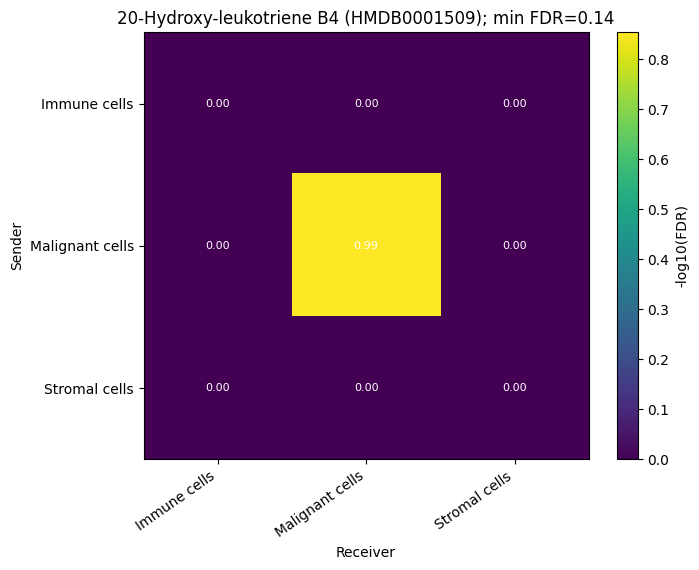

selected metabolite: 20-Hydroxy-leukotriene B4
selected hmdb_id: HMDB0001509
minimum FDR in selected metabolite: 0.14002828854314003
global minimum FDR: 0.14002828854314003


,sender,receiver,metabolite,hmdb_id,sensor_gene,sensor_type,cell_mesh_score,perm_pvalue,fdr
322,Immune cells,Immune cells,20-Hydroxy-leukotriene B4,HMDB0001509,LTB4R2,Cell surface receptor,0.000000,1.000000,1.000000
316,Immune cells,Malignant cells,20-Hydroxy-leukotriene B4,HMDB0001509,LTB4R2,Cell surface receptor,0.000000,1.000000,1.000000
319,Immune cells,Stromal cells,20-Hydroxy-leukotriene B4,HMDB0001509,LTB4R2,Cell surface receptor,0.000000,1.000000,1.000000
320,Malignant cells,Immune cells,20-Hydroxy-leukotriene B4,HMDB0001509,LTB4R2,Cell surface receptor,0.000000,1.000000,1.000000
0,Malignant cells,Malignant cells,20-Hydroxy-leukotriene B4,HMDB0001509,LTB4R2,Cell surface receptor,0.987053,0.009901,0.140028
317,Malignant cells,Stromal cells,20-Hydroxy-leukotriene B4,HMDB0001509,LTB4R2,Cell surface receptor,0.000000,1.000000,1.000000
321,Stromal cells,Immune cells,20-Hydroxy-leukotriene B4,HMDB0001509,LTB4R2,Cell surface receptor,0.000000,1.000000,1.000000
315,Stromal cells,Malignant cells,20-Hydroxy-leukotriene B4,HMDB0001509,LTB4R2,Cell surface receptor,0.000000,1.000000,1.000000
318,Stromal cells,Stromal cells,20-Hydroxy-leukotriene B4,HMDB0001509,LTB4R2,Cell surface receptor,0.000000,1.000000,1.000000


In [11]:
assert not res.events.empty
assert "fdr" in res.events.columns

fdr_events = res.events.dropna(subset=["fdr"]).copy()
assert not fdr_events.empty, "No events with FDR values are available; run with n_perms > 0."

min_fdr_event = fdr_events.sort_values(
    ["fdr", "cell_mesh_score"],
    ascending=[True, False],
).iloc[0]

target_metabolite = min_fdr_event["metabolite"]
target_hmdb_id = min_fdr_event["hmdb_id"]
target_min_fdr = float(min_fdr_event["fdr"])

target_events = res.events[
    (res.events["metabolite"] == target_metabolite)
    & (res.events["hmdb_id"] == target_hmdb_id)
].copy()

assert not target_events.empty, f"No events found for {target_metabolite} / {target_hmdb_id}"

plot_events = (
    target_events
    .sort_values(["sender", "receiver", "fdr", "cell_mesh_score"], ascending=[True, True, True, False])
    .drop_duplicates(["sender", "receiver"], keep="first")
)

score_matrix = plot_events.pivot(index="sender", columns="receiver", values="cell_mesh_score")
fdr_matrix = plot_events.pivot(index="sender", columns="receiver", values="fdr")
positive_fdr = fdr_matrix.where(fdr_matrix > 0).min().min()
min_positive_fdr = positive_fdr if pd.notna(positive_fdr) else 1.0 / (100 + 1)
log_fdr_matrix = -np.log10(fdr_matrix.clip(lower=min_positive_fdr))
plot_values = np.ma.masked_invalid(log_fdr_matrix.to_numpy(dtype=float))

fig, ax = plt.subplots(figsize=(1.4 * len(score_matrix.columns) + 3, 1.0 * len(score_matrix.index) + 2.8))
image = ax.imshow(plot_values, cmap="viridis", aspect="auto")

ax.set_xticks(np.arange(len(score_matrix.columns)))
ax.set_xticklabels(score_matrix.columns, rotation=35, ha="right")
ax.set_yticks(np.arange(len(score_matrix.index)))
ax.set_yticklabels(score_matrix.index)
ax.set_xlabel("Receiver")
ax.set_ylabel("Sender")
ax.set_title(f"{target_metabolite} ({target_hmdb_id}); min FDR={target_min_fdr:.3g}")

for i, sender in enumerate(score_matrix.index):
    for j, receiver in enumerate(score_matrix.columns):
        score = score_matrix.loc[sender, receiver]
        if pd.notna(score):
            ax.text(
                j,
                i,
                f"{score:.2f}",
                ha="center",
                va="center",
                color="white",
                fontsize=8,
            )

cbar = fig.colorbar(image, ax=ax)
cbar.set_label("-log10(FDR)")
fig.tight_layout()
plt.show()

print("selected metabolite:", target_metabolite)
print("selected hmdb_id:", target_hmdb_id)
print("minimum FDR in selected metabolite:", target_events["fdr"].min())
print("global minimum FDR:", fdr_events["fdr"].min())

display(
    plot_events[
        [
            "sender",
            "receiver",
            "metabolite",
            "hmdb_id",
            "sensor_gene",
            "sensor_type",
            "cell_mesh_score",
            "perm_pvalue",
            "fdr",
        ]
    ]
)


## 11. Optional Next Step

For a full analysis, increase `MAX_METABOLITES` or pass the full packaged priors to `run_cell_mesh()`. For empirical p-values and FDR, set `n_perms` to a positive value.
